In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import csv
import matplotlib.dates as mdates 
import seaborn as sns
from scipy.stats import norm, gmean, cauchy

In [106]:
# Look at the distribution of SPY, NVDA, TSMC and some sustainable energy company (NextEra Energy)

spy = yf.download('SPY', dt.datetime(2011, 1, 1), dt.date.today())
chips = yf.download(['NVDA', '2330.TW'], dt.datetime(2011, 1, 1), dt.date.today())
clean = yf.download('NEE', dt.datetime(2011, 1, 1), dt.date.today())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


In [107]:
chips['Close'].columns

Index(['2330.TW', 'NVDA'], dtype='object', name='Ticker')

In [108]:
chips.loc[:, ('Close', '2330.TW')]= chips['Close']['2330.TW']*0.03
chips.head()

Price          Close                 High                  Low            \
Ticker       2330.TW      NVDA    2330.TW      NVDA    2330.TW      NVDA   
Date                                                                       
2011-01-03  1.402706  0.362707  47.085669  0.366146  46.559576  0.355371   
2011-01-04  1.404678  0.361561  47.085666  0.365000  46.559572  0.353536   
2011-01-05  1.377059  0.389303  46.756863  0.389761  45.770431  0.364541   
2011-01-06  1.400733  0.443182  46.691101  0.443411  45.836192  0.398244   
2011-01-07  1.430326  0.455562  48.006350  0.456938  47.282968  0.428279   

Price            Open                 Volume                
Ticker        2330.TW      NVDA      2330.TW          NVDA  
Date                                                        
2011-01-03  47.019908  0.355829   35149000.0  8.174480e+08  
2011-01-04  46.691094  0.363395   35448000.0  6.513840e+08  
2011-01-05  46.625341  0.368210   51755000.0  1.428216e+09  
2011-01-06  45.901958  0.399391   46666000.0  3.493312e+09  
2011-01-07  47.282968  0.438137  169755000.0  2.579984e+09

In [109]:
chips.loc['2025-02-21']
print(chips.columns)
print(chips.iloc[0])
print(chips.index[0])
print(np.datetime64(chips.index[0], 'Y'))

MultiIndex([( 'Close', '2330.TW'),
            ( 'Close',    'NVDA'),
            (  'High', '2330.TW'),
            (  'High',    'NVDA'),
            (   'Low', '2330.TW'),
            (   'Low',    'NVDA'),
            (  'Open', '2330.TW'),
            (  'Open',    'NVDA'),
            ('Volume', '2330.TW'),
            ('Volume',    'NVDA')],
           names=['Price', 'Ticker'])
Price   Ticker 
Close   2330.TW    1.402706e+00
        NVDA       3.627072e-01
High    2330.TW    4.708567e+01
        NVDA       3.661463e-01
Low     2330.TW    4.655958e+01
        NVDA       3.553705e-01
Open    2330.TW    4.701991e+01
        NVDA       3.558291e-01
Volume  2330.TW    3.514900e+07
        NVDA       8.174480e+08
Name: 2011-01-03 00:00:00, dtype: float64
2011-01-03 00:00:00
2011


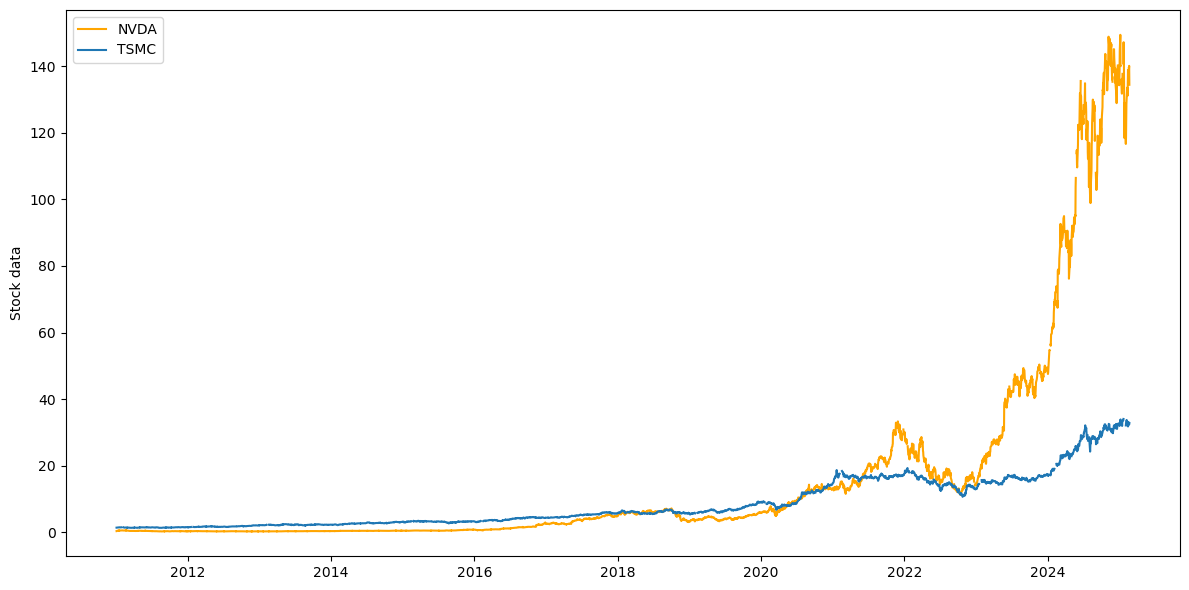

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(chips.index, chips['Close']['NVDA'], label='NVDA', color='orange')
plt.plot(chips.index, chips['Close']['2330.TW'], label='TSMC')
plt.ylabel('Stock data')
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

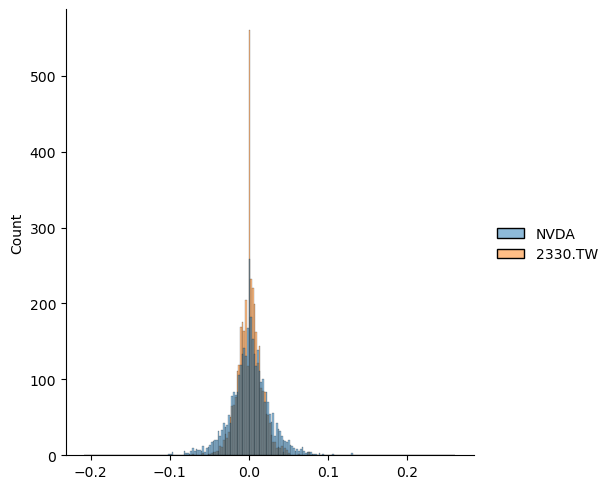

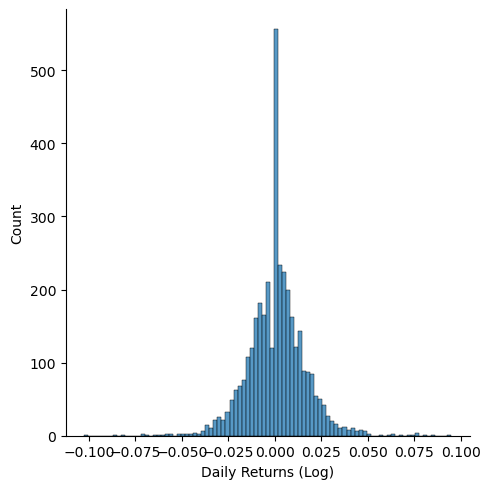

NVDA Average Daily Return:     0.1611%	 NVDA Yearly Average Return: 40.61%
TSMC Average Daily Return:     0.0859%	 TSMC Yearly Average Return: 21.65%


In [111]:
def log_returns(data):
  return (np.log(1+data))

relative = chips['Close'].pct_change()
log_ret = log_returns(relative)

nv_ret = log_ret['NVDA']
ts_ret = log_ret['2330.TW']

plt.figure(figsize=(12,7))
sns.displot([nv_ret, ts_ret], kde_kws={"color":"b","lw":1,"label":"NVDA"})
sns.displot(ts_ret, kde_kws={"color":"r","lw":1,"label":"TSMC"})
plt.xlabel("Daily Returns (Log)")
plt.show()
print(f"NVDA Average Daily Return: {round(nv_ret.mean()*100,4):{10}}%\t NVDA Yearly Average Return: {round(nv_ret.mean()*252*100,2)}%")
print(f"TSMC Average Daily Return: {round(ts_ret.mean()*100,4):{10}}%\t TSMC Yearly Average Return: {round(ts_ret.mean()*252*100,2)}%")

In [112]:
chips.to_csv("chips.csv")